[74.60147712 70.90194812 63.83497748 63.60958173 55.66362063 55.57918973
 48.12311755 48.07953769 41.17340938 41.14940325 34.80853986 34.79633654
 29.02711745 29.02381653 23.83492078 23.82950162 19.234266   19.21733027
 15.23151103 15.19368194  0.50000018  1.49999383  2.50008436  3.49910867
 11.85344135 11.76232298  4.50480355  5.47201758  7.27569289  6.57301753
  9.18807259  8.91583641]


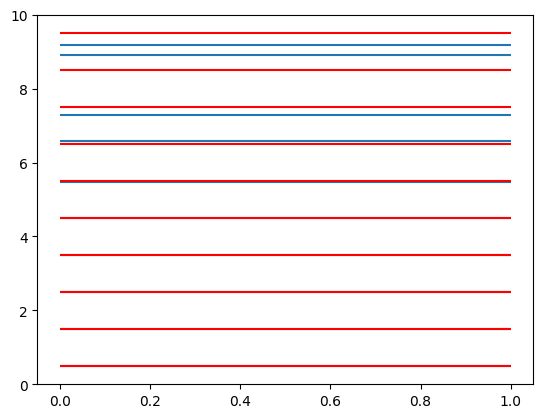

In [44]:
import numpy as np
import matplotlib.pyplot as plt

x_max = 4

n_q = 5

N = 2**n_q

j_array = np.arange(0, N)

delta_x = 2*x_max/(N-1)

x_eigenvalues = -x_max + delta_x*j_array

x_op = np.diag(x_eigenvalues)

delta_p = 2*np.pi/(delta_x * N)

p_max = np.pi/delta_x

p_eigenvalues = -p_max + delta_p * (j_array + 1/2)

p_diag = np.diag(p_eigenvalues)

omega = np.exp(-1j * 2 * np.pi / N)

ft = np.zeros((N,N), np.complex64)

for i in range(N):
    for j in range(N):
        #print(j+i)
        ft[i][j] = (1/np.sqrt(N)) * omega**(i*j)


ft_dag = np.conjugate(ft.T)

p_op = ft_dag @ p_diag @ ft

g = 1
beta_p = 1
beta_x = 1

H = (g**2 * beta_p**2 )/2 * (p_op @ p_op) + beta_x**2 / (2* g**2) * (x_op @ x_op)

eig_val, eig_vecs = np.linalg.eig(H)

energies = np.real(eig_val)

plt.hlines(energies,0, 1)

plt.ylim(0,10)

real_energies = (np.min(energies)*2) * (j_array + 1/2)

print(energies)

plt.hlines(real_energies, 0, 1, color="red")
